In [1]:
import pandas as pd
import numpy as np

df_ham = pd.read_csv('ai4i2020.csv')

# Gereksiz sütunları siliyoruz
gereksizler = ['UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
df_temiz = df_ham.drop(columns=gereksizler)

#  Kalan sütunları Türkçeleştiriyoruz
df_temiz.columns = [
    'Tip',              # Makine Kalitesi (L, M, H)
    'Hava_Sicakligi',   # Ortam Sıcaklığı
    'Islem_Sicakligi',  # Makine Sıcaklığı
    'Devir_Hizi',       # RPM
    'Tork',             # Güç
    'Takim_Asinmasi',   # Yıpranma Süresi
    'Ariza_Var_mi'      # Hedefimiz (0: Sağlam, 1: Bozuk)
]

print("Dosya okundu, gereksiz sütunlar silindi ve Türkçeleştirildi!")
print(df_temiz.head())

Dosya okundu, gereksiz sütunlar silindi ve Türkçeleştirildi!
  Tip  Hava_Sicakligi  Islem_Sicakligi  Devir_Hizi  Tork  Takim_Asinmasi  \
0   M           298.1            308.6        1551  42.8               0   
1   L           298.2            308.7        1408  46.3               3   
2   L           298.1            308.5        1498  49.4               5   
3   L           298.2            308.6        1433  39.5               7   
4   L           298.2            308.7        1408  40.0               9   

   Ariza_Var_mi  
0             0  
1             0  
2             0  
3             0  
4             0  


In [2]:
# 1. Tip  sütunundaki harfleri sayılara çeviriyoruz
# L (Düşük): 0, M (Orta): 1, H (Yüksek): 2
df_temiz['Tip'] = df_temiz['Tip'].map({'L': 0, 'M': 1, 'H': 2})

# 2. Eksik veya bozuk veri var mı
df_temiz.dropna(inplace=True)

print(" Harfler sayılara çevrildi")
print(df_temiz.info())

 Harfler sayılara çevrildi
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Tip              10000 non-null  int64  
 1   Hava_Sicakligi   10000 non-null  float64
 2   Islem_Sicakligi  10000 non-null  float64
 3   Devir_Hizi       10000 non-null  int64  
 4   Tork             10000 non-null  float64
 5   Takim_Asinmasi   10000 non-null  int64  
 6   Ariza_Var_mi     10000 non-null  int64  
dtypes: float64(3), int64(4)
memory usage: 547.0 KB
None


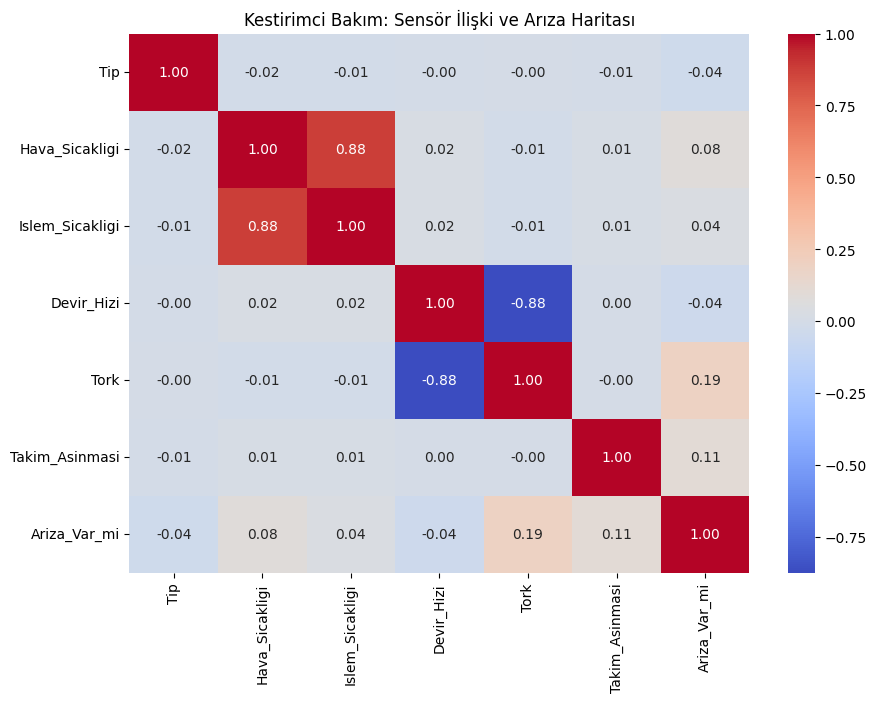


 Sensörlerin birbiriyle ve arızayla olan ilişkisi çizdirildi.


In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
# Arıza ve sensörler arasındaki korelasyon
sns.heatmap(df_temiz.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Kestirimci Bakım: Sensör İlişki ve Arıza Haritası')
plt.show()

print("\n Sensörlerin birbiriyle ve arızayla olan ilişkisi çizdirildi.")

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Sorular (Sensör Verileri) ve Hedef Cevap (Arıza)
X = df_temiz.drop('Ariza_Var_mi', axis=1)
y = df_temiz['Ariza_Var_mi']

#  Eğitim %80 Test %20
X_egitim, X_test, y_egitim, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest Modelini çağırıp eğitiyoruz
model_bakim = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model_bakim.fit(X_egitim, y_egitim)

# Sınav Sonuçları
tahminler = model_bakim.predict(X_test)
print(f" Modelin Gerçek Verideki Genel Başarı Oranı: % {accuracy_score(y_test, tahminler) * 100:.2f}")
print("\n Detaylı Yapay Zeka Arıza Tespit Karnesi:")
print(classification_report(y_test, tahminler))

 Modelin Gerçek Verideki Genel Başarı Oranı: % 98.20

 Detaylı Yapay Zeka Arıza Tespit Karnesi:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1939
           1       0.88      0.48      0.62        61

    accuracy                           0.98      2000
   macro avg       0.93      0.74      0.80      2000
weighted avg       0.98      0.98      0.98      2000



In [6]:

#  Fabrikadan 2 yeni makinenin canlı sensör verileri geliyor
yeni_makineler = pd.DataFrame({
    'Makine_Adi': ['Makine_A (Normal)', 'Makine_B (Zorlanan)'],
    'Tip': [2, 0],
    'Hava_Sicakligi': [298.1, 304.5],
    'Islem_Sicakligi': [308.6, 315.2],
    'Devir_Hizi': [1551, 1300],
    'Tork': [42.8, 65.5],
    'Takim_Asinmasi': [0, 210]
})

print(" CANLI SENSÖR VERİLERİ ALINDI:")
print(yeni_makineler.to_string(index=False))
print("-" * 10)

# Makine adını çıkarıp tahmin yapıyoruz
test_verisi = yeni_makineler.drop('Makine_Adi', axis=1)
kararlar = model_bakim.predict(test_verisi)

# Sonuç Ekranı
for i in range(len(kararlar)):
    isim = yeni_makineler['Makine_Adi'][i]
    if kararlar[i] == 1:
        print(f" {isim} -> RİSK: ARIZA BEKLENİYOR! ACİL BAKIMA ALIN!")
    else:
        print(f" {isim} -> DURUM: NORMAL. ÇALIŞMAYA DEVAM EDEBİLİR.")

 CANLI SENSÖR VERİLERİ ALINDI:
         Makine_Adi  Tip  Hava_Sicakligi  Islem_Sicakligi  Devir_Hizi  Tork  Takim_Asinmasi
  Makine_A (Normal)    2           298.1            308.6        1551  42.8               0
Makine_B (Zorlanan)    0           304.5            315.2        1300  65.5             210
----------
 Makine_A (Normal) -> DURUM: NORMAL. ÇALIŞMAYA DEVAM EDEBİLİR.
 Makine_B (Zorlanan) -> RİSK: ARIZA BEKLENİYOR! ACİL BAKIMA ALIN!
